# Part 3: Multimodal Models

This notebook demonstrates the classic Foundry multimodal flow with three types of inputs:
1. Image understanding.
2. Audio understanding.
3. Mixed prompts that combine text with image and audio inputs.

The notebook is self-contained: it generates a sample image and a sample WAV audio clip locally, then sends them to the classic Foundry models endpoint with a multimodal deployment such as Phi-4-multimodal-instruct.

## 0) Setup and Configuration

In this section we will:
- Load environment variables from `.env`.
- Initialize the multimodal client.
- Create local demo assets for image and audio.
- Verify that the notebook can display the assets before calling the model.

Loaded environment variables successfully.
Classic models endpoint: https://01-ai-foundry-basics-2-resource.services.ai.azure.com/models
Model deployment: Phi-4-multimodal-instruct
Audio deployment: gpt-audio-1.5
Assignment dir: c:\Users\Lucian\Desktop\Tajamar\IA Generativa\gen-ai-assignments\01-ai-foundry-basics
Image asset: c:\Users\Lucian\Desktop\Tajamar\IA Generativa\gen-ai-assignments\01-ai-foundry-basics\images\03_multimodal_demo_scene.png
Audio asset: c:\Users\Lucian\Desktop\Tajamar\IA Generativa\gen-ai-assignments\01-ai-foundry-basics\assets\03_multimodal_demo_tone.wav

Generated image preview:


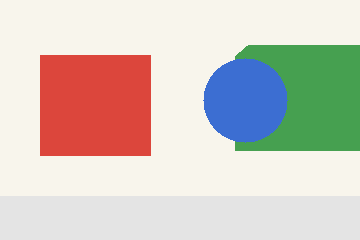

Generated audio preview:


In [ ]:
"""Setup cell for the multimodal notebook.

What this cell does:
1) Loads credentials and configuration from .env
2) Validates the required settings early
3) Creates a classic Foundry multimodal client
4) Generates local demo image/audio assets
5) Displays the generated assets inline
"""

import io
import json
import math
import os
import struct
import wave
import zlib
from pathlib import Path

from azure.ai.inference import ChatCompletionsClient
from azure.ai.inference.models import (
    AudioContentFormat,
    AudioContentItem,
    ImageContentItem,
    ImageUrl,
    InputAudio,
    SystemMessage,
    TextContentItem,
    UserMessage,
)
from azure.core.credentials import AzureKeyCredential
from dotenv import load_dotenv
from IPython.display import Audio, Image, display

# Load local environment variables. override=True ensures the notebook picks up the latest .env values.
load_dotenv(override=True)

# Read the runtime configuration used by the notebook.
FOUNDRY_ENDPOINT = os.getenv("FOUNDRY_ENDPOINT", "").strip()
FOUNDRY_MODELS_ENDPOINT = os.getenv("FOUNDRY_MODELS_ENDPOINT", FOUNDRY_ENDPOINT).strip()
FOUNDRY_API_KEY = os.getenv("FOUNDRY_API_KEY", "").strip()
MODEL_DEPLOYMENT = os.getenv("MODEL_DEPLOYMENT", "").strip()
MULTIMODAL_MODEL_DEPLOYMENT = os.getenv("MULTIMODAL_MODEL_DEPLOYMENT", MODEL_DEPLOYMENT).strip()
AUDIO_MODEL_DEPLOYMENT = os.getenv("AUDIO_MODEL_DEPLOYMENT", MULTIMODAL_MODEL_DEPLOYMENT).strip()

# Fail fast if a required setting is missing.
missing = [
    name
    for name, value in [
        ("FOUNDRY_MODELS_ENDPOINT", FOUNDRY_MODELS_ENDPOINT),
        ("FOUNDRY_API_KEY", FOUNDRY_API_KEY),
        ("MULTIMODAL_MODEL_DEPLOYMENT or MODEL_DEPLOYMENT", MULTIMODAL_MODEL_DEPLOYMENT),
    ]
    if not value
]

if missing:
    raise ValueError(
        "Missing required environment variables: "
        + ", ".join(missing)
        + ". Set them in your .env file and rerun this cell."
    )

# Normalize the classic Foundry endpoint and reject project endpoints.
classic_endpoint = FOUNDRY_MODELS_ENDPOINT.rstrip("/")
if "/api/projects/" in classic_endpoint:
    raise ValueError(
        "FOUNDRY_MODELS_ENDPOINT must point to the classic Foundry resource endpoint, not a project endpoint. "
        "Use the resource URL ending in /models, for example https://<resource>.services.ai.azure.com/models."
    )
if not classic_endpoint.endswith("/models"):
    classic_endpoint = classic_endpoint + "/models"

# Build the client used by the image and audio requests below.
client = ChatCompletionsClient(
    endpoint=classic_endpoint,
    credential=AzureKeyCredential(FOUNDRY_API_KEY),
    model=MULTIMODAL_MODEL_DEPLOYMENT,
)

# Resolve the assignment folder whether the notebook is opened at the repo root or inside the assignment folder.
assignment_dir = Path.cwd()
if (assignment_dir / "01-ai-foundry-basics").exists():
    assignment_dir = assignment_dir / "01-ai-foundry-basics"

images_dir = assignment_dir / "images"
assets_dir = assignment_dir / "assets"
images_dir.mkdir(parents=True, exist_ok=True)
assets_dir.mkdir(parents=True, exist_ok=True)
image_path = images_dir / "03_multimodal_demo_scene.png"
audio_path = assets_dir / "03_multimodal_demo_tone.wav"


def png_chunk(tag: bytes, payload: bytes) -> bytes:
    return struct.pack(">I", len(payload)) + tag + payload + struct.pack(">I", zlib.crc32(tag + payload) & 0xFFFFFFFF)


def build_demo_png_bytes() -> bytes:
    """Create a small PNG scene with simple shapes."""
    width = 360
    height = 240
    rows = []
    for y in range(height):
        row = bytearray([0])
        for x in range(width):
            if y > 195:
                rgb = (228, 228, 228)
            elif 40 <= x <= 150 and 55 <= y <= 155:
                rgb = (220, 70, 60)
            elif (x - 245) ** 2 + (y - 100) ** 2 <= 42 ** 2:
                rgb = (60, 110, 210)
            elif x >= 235 and y >= 45 and y <= 150 and y > (-0.85 * x + 255):
                rgb = (70, 160, 80)
            else:
                rgb = (248, 245, 236)
            row.extend(rgb)
        rows.append(bytes(row))

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    idat = zlib.compress(b"".join(rows), level=9)
    return b"\x89PNG\r\n\x1a\n" + png_chunk(b"IHDR", ihdr) + png_chunk(b"IDAT", idat) + png_chunk(b"IEND", b"")


def build_demo_wav_bytes() -> bytes:
    """Create a short WAV file with three tones separated by brief silence."""
    sample_rate = 16000
    segments = [
        (440, 0.35),
        (0, 0.10),
        (660, 0.35),
        (0, 0.10),
        (550, 0.35),
    ]
    frame_bytes = bytearray()
    for frequency, duration in segments:
        total_samples = int(sample_rate * duration)
        for index in range(total_samples):
            if frequency == 0:
                sample = 0
            else:
                sample = int(0.35 * 32767 * math.sin(2 * math.pi * frequency * index / sample_rate))
            frame_bytes.extend(struct.pack("<h", sample))

    buffer = io.BytesIO()
    with wave.open(buffer, "wb") as wav_file:
        wav_file.setnchannels(1)
        wav_file.setsampwidth(2)
        wav_file.setframerate(sample_rate)
        wav_file.writeframes(bytes(frame_bytes))
    return buffer.getvalue()


# Generate the local demo files used in the notebook examples.
image_bytes = build_demo_png_bytes()
audio_bytes = build_demo_wav_bytes()
image_path.write_bytes(image_bytes)
audio_path.write_bytes(audio_bytes)
image_url = ImageUrl.load(image_file=str(image_path), image_format="png")
audio_input = InputAudio.load(audio_file=str(audio_path), audio_format=AudioContentFormat.WAV)


def extract_text(response) -> str:
    if not getattr(response, "choices", None):
        return ""
    message = response.choices[0].message
    content = getattr(message, "content", "") or ""
    return content.strip() if isinstance(content, str) else str(content).strip()


def parse_json_block(text: str) -> dict:
    """Parse JSON even when the model wraps it in markdown code fences."""
    cleaned = text.strip()
    if cleaned.startswith("```"):
        lines = cleaned.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[0].strip().lower() == "json":
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        cleaned = "\n".join(lines).strip()
    return json.loads(cleaned)


# Show the resolved configuration and generated files before making any model calls.
print("Loaded environment variables successfully.")
print(f"Classic models endpoint: {classic_endpoint}")
print(f"Model deployment: {MULTIMODAL_MODEL_DEPLOYMENT}")
print(f"Audio deployment: {AUDIO_MODEL_DEPLOYMENT}")
print(f"Assignment dir: {assignment_dir}")
print(f"Image asset: {image_path}")
print(f"Audio asset: {audio_path}")

print("\nGenerated image preview:")
display(Image(data=image_bytes))
print("Generated audio preview:")
display(Audio(data=audio_bytes, rate=16000))

## 3.1) Image Understanding

Goal: Send a local PNG image to the classic Foundry multimodal model and request a structured description.

This example follows the Microsoft Learn pattern: one multimodal model deployment, a typed user message, and a JSON response that can be validated and parsed in the notebook.

In [ ]:
"""Describe the generated image with structured output."""

# Image + text is the supported multimodal path for this notebook.
# The prompt asks for JSON so the output can be validated and reused later.

image_messages = [
    SystemMessage("You are a visual analyst. Return only valid JSON."),
    UserMessage(
        content=[
            TextContentItem(
                text=(
                    "Inspect the image and return a JSON object with keys: scene_summary, visible_objects, "
                    "dominant_colors, and confidence_notes. Do not wrap the JSON in markdown fences."
                )
            ),
            ImageContentItem(image_url=image_url),
        ]
    ),
]

try:
    image_response = client.complete(
        messages=image_messages,
        temperature=0.2,
        max_tokens=500,
    )
    image_text = extract_text(image_response)
    print("Image analysis raw response:")
    print(image_text)

    try:
        image_json = parse_json_block(image_text)
        print("\nParsed image summary:")
        print(image_json.get("scene_summary", "[missing scene_summary]"))
    except json.JSONDecodeError:
        print("\nThe response was not valid JSON. The raw text above is still usable for the report.")
except Exception as exc:
    print("Image analysis failed.")
    print(f"Error type: {type(exc).__name__}")
    print(f"Error detail: {exc}")
    print("If the deployment does not support image input, verify the classic multimodal model deployment and rerun.")

Image analysis raw response:
{
  "scene_summary": "The image shows a simple scene with two geometric shapes.",
  "visible_objects": [
    {
      "type": "rectangle",
      "color": "red",
      "position": "left"
    },
    {
      "type": "circle",
      "color": "blue",
      "position": "right"
    }
  ],
  "dominant_colors": [
    "red",
    "blue",
    "green"
  ],
  "confidence_notes": "The objects are clearly visible and their colors are distinct."
}

Parsed image summary:
The image shows a simple scene with two geometric shapes.


## How I read this result

I expect a structured JSON description of the image, followed by a shorter parsed summary that I can use in the report.

If the model returns plain text instead of valid JSON, I can still review the raw output to see what it recognized.

## 3.2) Audio Understanding

Goal: Send a local WAV audio clip to the model and ask for a structured interpretation.

The demo audio is a synthetic tone sequence, so the prompt explicitly asks the model to describe the pattern rather than transcribe human speech.

In [ ]:
"""Describe the generated audio clip with structured output."""

# Audio + text is used as a separate call so the notebook stays within the model capability.
# The prompt asks for JSON so the response can be parsed consistently.

audio_messages = [
    SystemMessage("You are an audio analyst. Return only valid JSON."),
    UserMessage(
        content=[
            TextContentItem(
                text=(
                    "This clip is a synthetic tone sequence created for the notebook. Return a JSON object with keys: "
                    "speech_detected, summary, pattern_guess, and confidence_notes. Do not wrap the JSON in markdown fences."
                )
            ),
            AudioContentItem(input_audio=audio_input),
        ]
    ),
]

try:
    audio_response = client.complete(
        messages=audio_messages,
        temperature=0.2,
        max_tokens=500,
    )
    audio_text = extract_text(audio_response)
    print("Audio analysis raw response:")
    print(audio_text)

    try:
        audio_json = parse_json_block(audio_text)
        print("\nParsed audio summary:")
        print(audio_json.get("summary", "[missing summary]"))
    except json.JSONDecodeError:
        print("\nThe response was not valid JSON. The raw text above is still usable for the report.")
except Exception as exc:
    print("Audio analysis failed.")
    print(f"Error type: {type(exc).__name__}")
    print(f"Error detail: {exc}")
    print("If the deployment does not support audio input, verify the classic multimodal model deployment and rerun.")

Audio analysis raw response:
{ "speech_detected": false, "summary": "The audio clip is a synthetic tone sequence created for a notebook.", "pattern_guess": "The audio clip is a sequence of tones with no discernible pattern.", "confidence_notes": "The confidence level is high as the audio clip is clearly synthetic and lacks any natural speech or recognizable patterns." }

Parsed audio summary:
The audio clip is a synthetic tone sequence created for a notebook.


## How I read this result

I expect the clip to be treated as synthetic audio, so I describe the tone pattern instead of any human speech.

The parsed summary is the part I compare against the prompt to see whether the model followed the instruction.

## 3.3) Mixed Prompt

Goal: Combine the image and audio results into one final answer without forcing the model to accept image, audio, and text all in the same prompt.

This section reflects the model limitation: Phi-4-multimodal-instruct can handle image and audio separately, but not all three modalities together in one request.

In [ ]:
"""Run a multimodal summary without sending image, audio, and text together in one prompt."""

# Phi-4-multimodal-instruct does not support image + audio + text in a single prompt.
# The notebook therefore uses a two-step pattern: analyze image and audio separately,
# then synthesize one final answer from those results.

image_only_messages = [
    SystemMessage("You are a visual analyst. Return only valid JSON."),
    UserMessage(
        content=[
            TextContentItem(
                text=(
                    "Inspect the image and return a JSON object with keys: scene_summary, visible_objects, "
                    "dominant_colors, and confidence_notes. Do not wrap the JSON in markdown fences."
                )
            ),
            ImageContentItem(image_url=image_url),
        ]
    ),
]

audio_only_messages = [
    SystemMessage("You are an audio analyst. Return only valid JSON."),
    UserMessage(
        content=[
            TextContentItem(
                text=(
                    "This clip is a synthetic tone sequence created for the notebook. Return a JSON object with keys: "
                    "speech_detected, summary, pattern_guess, and confidence_notes. Do not wrap the JSON in markdown fences."
                )
            ),
            AudioContentItem(input_audio=audio_input),
        ]
    ),
]

try:
    # First, get a structured summary of the image.
    image_only_response = client.complete(
        messages=image_only_messages,
        temperature=0.2,
        max_tokens=500,
    )
    image_only_text = extract_text(image_only_response)
    image_only_json = parse_json_block(image_only_text)
    print("Image summary:")
    print(image_only_json.get("scene_summary", "[missing scene_summary]"))

    # Then, get a structured summary of the audio.
    audio_only_response = client.complete(
        messages=audio_only_messages,
        temperature=0.2,
        max_tokens=500,
    )
    audio_only_text = extract_text(audio_only_response)
    audio_only_json = parse_json_block(audio_only_text)
    print("\nAudio summary:")
    print(audio_only_json.get("summary", "[missing summary]"))

    # Finally, combine both results in a text-only synthesis step.
    synthesis_messages = [
        SystemMessage("You are a multimodal assistant. Return a concise JSON object."),
        UserMessage(
            content=(
                "Combine these modality summaries into one JSON object with keys: image_takeaways, "
                "audio_takeaways, combined_interpretation, and one_sentence_recommendation. "
                "Do not wrap the JSON in markdown fences.\n\n"
                f"Image summary: {image_only_json.get('scene_summary', '[missing scene_summary]')}\n"
                f"Image objects: {image_only_json.get('visible_objects', '[missing visible_objects]')}\n"
                f"Audio summary: {audio_only_json.get('summary', '[missing summary]')}\n"
                f"Audio pattern guess: {audio_only_json.get('pattern_guess', '[missing pattern_guess]')}"
            )
        ),
    ]

    synthesis_response = client.complete(
        messages=synthesis_messages,
        temperature=0.2,
        max_tokens=500,
    )
    synthesis_text = extract_text(synthesis_response)
    print("\nCombined response:")
    print(synthesis_text)

    try:
        synthesis_json = parse_json_block(synthesis_text)
        print("\nParsed combined interpretation:")
        print(synthesis_json.get("combined_interpretation", "[missing combined_interpretation]"))
    except json.JSONDecodeError:
        print("\nThe response was not valid JSON. The raw text above is still usable for the report.")
except Exception as exc:
    print("Mixed multimodal analysis failed.")
    print(f"Error type: {type(exc).__name__}")
    print(f"Error detail: {exc}")
    print("If the deployment does not support one of the separate modality calls, verify the classic multimodal model deployment and rerun.")

Image summary:
The image features two geometric shapes, a red square and a green rectangle, with a blue circle overlapping them.

Audio summary:
The audio clip is a synthetic tone sequence created for the notebook.

Combined response:
{
  "image_takeaways": "Two geometric shapes, a red square and a green rectangle, with a blue circle overlapping them.",
  "audio_takeaways": "A synthetic tone sequence created for the notebook.",
  "combined_interpretation": "An image with overlapping geometric shapes and a synthetic audio tone.",
  "one_sentence_recommendation": "Explore the interaction between visual and synthetic audio elements."
}

Parsed combined interpretation:
An image with overlapping geometric shapes and a synthetic audio tone.


## How I combine the outputs

I first summarize the image and audio separately, then I combine those summaries in a final text-only synthesis step.

That final interpretation shows the pattern I use when I need to avoid an unsupported image + audio + text prompt.

## Final Conclusions

Observed outcomes:

- The notebook uses the classic Foundry models endpoint and generates local demo assets so it stays reproducible.
- Image + text is handled in one call, audio + text is handled in one call, and the mixed result is built from separate analyses instead of forcing an unsupported triple-modal prompt.
- The classic endpoint must be the Foundry resource models endpoint, not a project `/api/projects/...` endpoint.

Issues encountered:

- Phi-4-multimodal-instruct does not support image + audio + text in a single prompt.
- JSON output is easier to validate when each prompt asks for one clear structure and the synthesis step stays text-only.
- The split-call pattern is the reliable approach unless a model’s documentation explicitly supports all three modalities together.